# Análise da cena brasileira de CS:GO

Estudo ponta a ponta da representação brasileira no dataset HLTV, com foco em:

1. **Panorama da cena BR** (volume, idade, times atuais)
2. **Idade vs. performance** entre os brasileiros
3. **Ranking e perfil dos melhores jogadores brasileiros**
4. **Análise dos times brasileiros**
5. **Brasil vs. Mundo**:
    - Melhor jogador brasileiro × melhor jogador do mundo
    - Melhor time brasileiro × melhor time do mundo
6. **Exportações para Power BI** (CSVs prontos para importação)

**Fonte:** `csgo_players.csv` (811 jogadores profissionais, 41 métricas agregadas de carreira HLTV).

## 0. Setup, carga e limpeza

- Carrega o CSV.
- Converte colunas de percentual (`headshot_percentage`, `team_win_percent_after_first_kill`, `first_kill_in_won_rounds`) de string para `float`.
- Recalcula `kill_to_death_diff` (vinha quebrado do scraping).
- Cria `has_team`, `age_group` e shares de armas (`rifle_share`, `sniper_share`, ...).
- Marca cada jogador como `is_brazilian` para facilitar filtros.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9

BR_COLOR = '#009C3B'
BR_ACCENT = '#FFDF00'
WORLD_COLOR = '#2f80ed'
NEUTRAL = '#6c757d'
HIGHLIGHT = '#eb5757'

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 140)

In [2]:
df = pd.read_csv('csgo_players.csv')

pct_cols = ['headshot_percentage', 'team_win_percent_after_first_kill', 'first_kill_in_won_rounds']
for c in pct_cols:
    if not pd.api.types.is_numeric_dtype(df[c]):
        df[c] = df[c].astype(str).str.rstrip('%').astype(float)

df['kill_to_death_diff'] = df['total_kills'] - df['total_deaths']
df['has_team'] = df['current_team'].notna()
df['is_brazilian'] = df['country'] == 'Brazil'

age_bins = [16, 20, 23, 26, 29, 40]
age_labels = ['<=20', '21-23', '24-26', '27-29', '30+']
df['age_group'] = pd.cut(df['age'], bins=age_bins, labels=age_labels, right=True)

weapon_cols = ['rifle_kills', 'sniper_kills', 'smg_kills', 'pistol_kills', 'grenade_kills', 'other_kills']
weapon_share_cols = []
for col in weapon_cols:
    share_col = col.replace('_kills', '_share')
    df[share_col] = df[col] / df['total_kills']
    weapon_share_cols.append(share_col)

brazil_df = df[df['is_brazilian']].copy()
world_df = df.copy()

print(f'Dataset total: {len(df)} jogadores | {df["country"].nunique()} países')
print(f'Brasileiros: {len(brazil_df)} ({len(brazil_df)/len(df):.1%} do total)')
df.head(3)

Dataset total: 811 jogadores | 53 países
Brasileiros: 61 (7.5% do total)


,player_id,nickname,real_name,age,country,current_team,teams,total_kills,total_deaths,headshot_percentage,damage_per_round,grenade_dmg_per_round,maps_played,rounds_played,kills_per_death,kills_per_round,assists_per_round,deaths_per_round,saved_by_teammate_per_round,saved_teammates_per_round,rounds_with_kills,kill_to_death_diff,total_opening_kills,total_opening_deaths,opening_kill_ratio,opening_kill_rating,team_win_percent_after_first_kill,first_kill_in_won_rounds,0_kill_rounds,1_kill_rounds,2_kill_rounds,3_kill_rounds,4_kill_rounds,5_kill_rounds,rifle_kills,sniper_kills,smg_kills,pistol_kills,grenade_kills,other_kills,rating,has_team,is_brazilian,age_group,rifle_share,sniper_share,smg_share,pistol_share,grenade_share,other_share
0,11893,ZywOo,Mathieu Herbaut,21,France,Vitality,"Vitality, aAa",22622,16458,41.2,88.0,3.6,1020,26803,1.37,0.84,0.12,0.61,0.10,0.12,14196,6164,4152,2592,1.60,1.28,73.1,21.4,12607,8195,4087,1474,369,71,8261,8552,1290,4262,260,49,1.32,True,False,21-23,0.365175,0.378039,0.057024,0.188401,0.011493,0.002166
1,7998,s1mple,Aleksandr Kostyliev,24,Ukraine,Natus Vincere,Natus Vincere,35512,26413,41.3,86.4,2.4,1571,41491,1.34,0.86,0.10,0.64,0.08,0.11,22559,9099,6014,3734,1.61,1.24,75.2,20.8,18932,13085,6644,2262,504,64,14717,13451,901,6057,199,254,1.25,True,False,24-26,0.414423,0.378773,0.025372,0.170562,0.005604,0.007153
2,16920,sh1ro,Dmitry Sokolov,21,Russia,Cloud9,"Gambit Youngsters, Gambit",18091,12492,27.8,78.6,3.9,884,23451,1.45,0.77,0.11,0.53,0.08,0.11,11950,5599,2705,1383,1.96,1.15,77.0,16.2,11501,7416,3208,1075,221,30,3791,10580,550,3008,175,70,1.26,True,False,21-23,0.209552,0.584821,0.030402,0.166271,0.009673,0.003869


## 1. Panorama da cena brasileira

Posição do Brasil em volume de jogadores em comparação aos demais países.

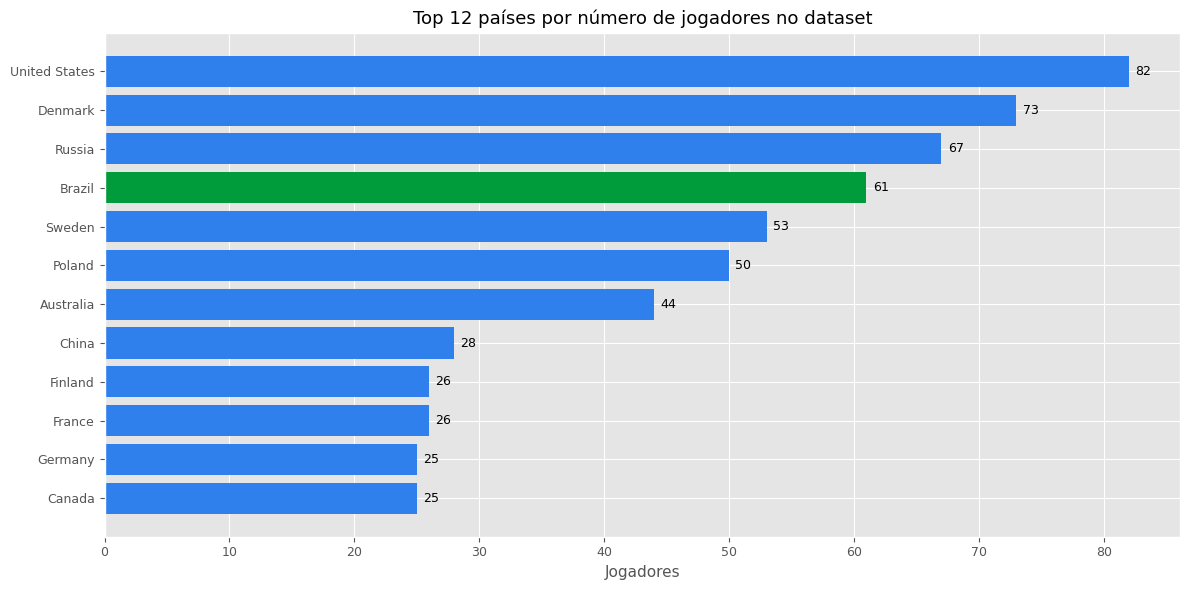

Brasil ocupa a 4ª posição em número de jogadores (61).


In [3]:
country_size = df['country'].value_counts().head(12)
plot_data = country_size.sort_values()

fig, ax = plt.subplots(figsize=(12, 6))
colors = [BR_COLOR if c == 'Brazil' else WORLD_COLOR for c in plot_data.index]
bars = ax.barh(plot_data.index, plot_data.values, color=colors)
for bar, val in zip(bars, plot_data.values):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2, str(val), va='center', fontsize=9)
ax.set_title('Top 12 países por número de jogadores no dataset')
ax.set_xlabel('Jogadores')
plt.tight_layout()
plt.show()

br_rank = (df['country'].value_counts().index == 'Brazil').argmax() + 1
print(f'Brasil ocupa a {br_rank}ª posição em número de jogadores ({len(brazil_df)}).')

In [4]:
br_active = brazil_df['has_team'].sum()
br_inactive = (~brazil_df['has_team']).sum()
br_teams = brazil_df.dropna(subset=['current_team'])['current_team'].nunique()
br_age_mean = brazil_df['age'].mean()
br_rating_mean = brazil_df['rating'].mean()

summary = pd.Series({
    'Jogadores brasileiros': len(brazil_df),
    'Com time atual': br_active,
    'Sem time (aposentados / FA)': br_inactive,
    'Times atuais distintos': br_teams,
    'Idade média': round(br_age_mean, 1),
    'Rating médio': round(br_rating_mean, 3),
    'Rating médio (global)': round(df['rating'].mean(), 3),
})
summary.to_frame('Brasil')

,Brasil
Jogadores brasileiros,61.000
Com time atual,43.000
Sem time (aposentados / FA),18.000
Times atuais distintos,12.000
Idade média,25.900
Rating médio,1.063
Rating médio (global),1.034


## 2. Idade vs. performance no Brasil

Comparamos a curva idade × rating do Brasil com o resto do mundo e calculamos a correlação para a amostra brasileira isoladamente.

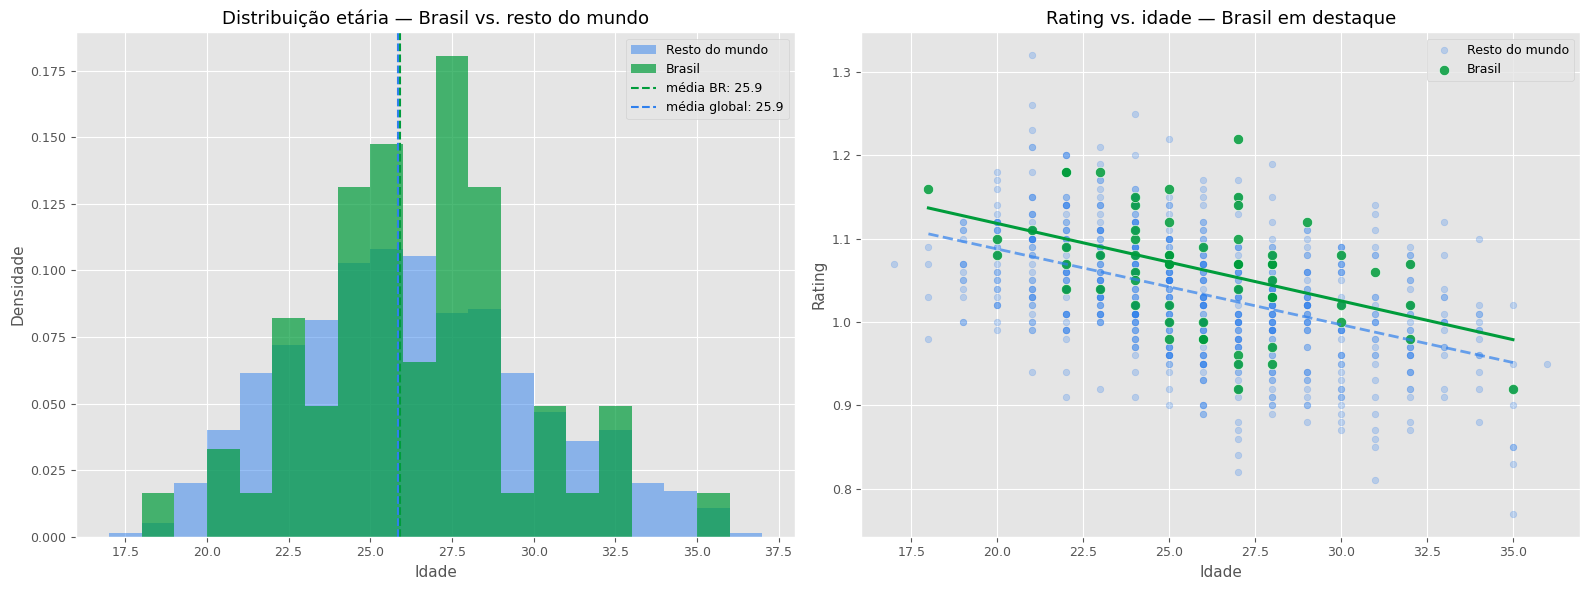

Correlação idade × rating — Brasil: -0.448  |  Global: -0.462


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
bins = np.arange(df['age'].min(), df['age'].max() + 2)
ax.hist(df.loc[~df['is_brazilian'], 'age'], bins=bins, alpha=0.5,
        color=WORLD_COLOR, label='Resto do mundo', density=True)
ax.hist(brazil_df['age'], bins=bins, alpha=0.7,
        color=BR_COLOR, label='Brasil', density=True)
ax.axvline(brazil_df['age'].mean(), color=BR_COLOR, linestyle='--',
           label=f'média BR: {brazil_df["age"].mean():.1f}')
ax.axvline(df['age'].mean(), color=WORLD_COLOR, linestyle='--',
           label=f'média global: {df["age"].mean():.1f}')
ax.set_title('Distribuição etária — Brasil vs. resto do mundo')
ax.set_xlabel('Idade')
ax.set_ylabel('Densidade')
ax.legend(fontsize=9)

ax = axes[1]
ax.scatter(df.loc[~df['is_brazilian'], 'age'], df.loc[~df['is_brazilian'], 'rating'],
           s=22, alpha=0.25, color=WORLD_COLOR, label='Resto do mundo')
ax.scatter(brazil_df['age'], brazil_df['rating'],
           s=55, alpha=0.85, color=BR_COLOR, edgecolors='white', linewidth=0.5, label='Brasil')
z_br = np.polyfit(brazil_df['age'], brazil_df['rating'], 1)
xs = np.linspace(brazil_df['age'].min(), brazil_df['age'].max(), 100)
ax.plot(xs, np.poly1d(z_br)(xs), color=BR_COLOR, linewidth=2.2)
z_world = np.polyfit(df['age'], df['rating'], 1)
ax.plot(xs, np.poly1d(z_world)(xs), color=WORLD_COLOR, linewidth=2, linestyle='--', alpha=0.7)
ax.set_title('Rating vs. idade — Brasil em destaque')
ax.set_xlabel('Idade')
ax.set_ylabel('Rating')
ax.legend(fontsize=9, loc='upper right')

plt.tight_layout()
plt.show()

corr_br = brazil_df['age'].corr(brazil_df['rating'])
corr_world = df['age'].corr(df['rating'])
print(f'Correlação idade × rating — Brasil: {corr_br:+.3f}  |  Global: {corr_world:+.3f}')

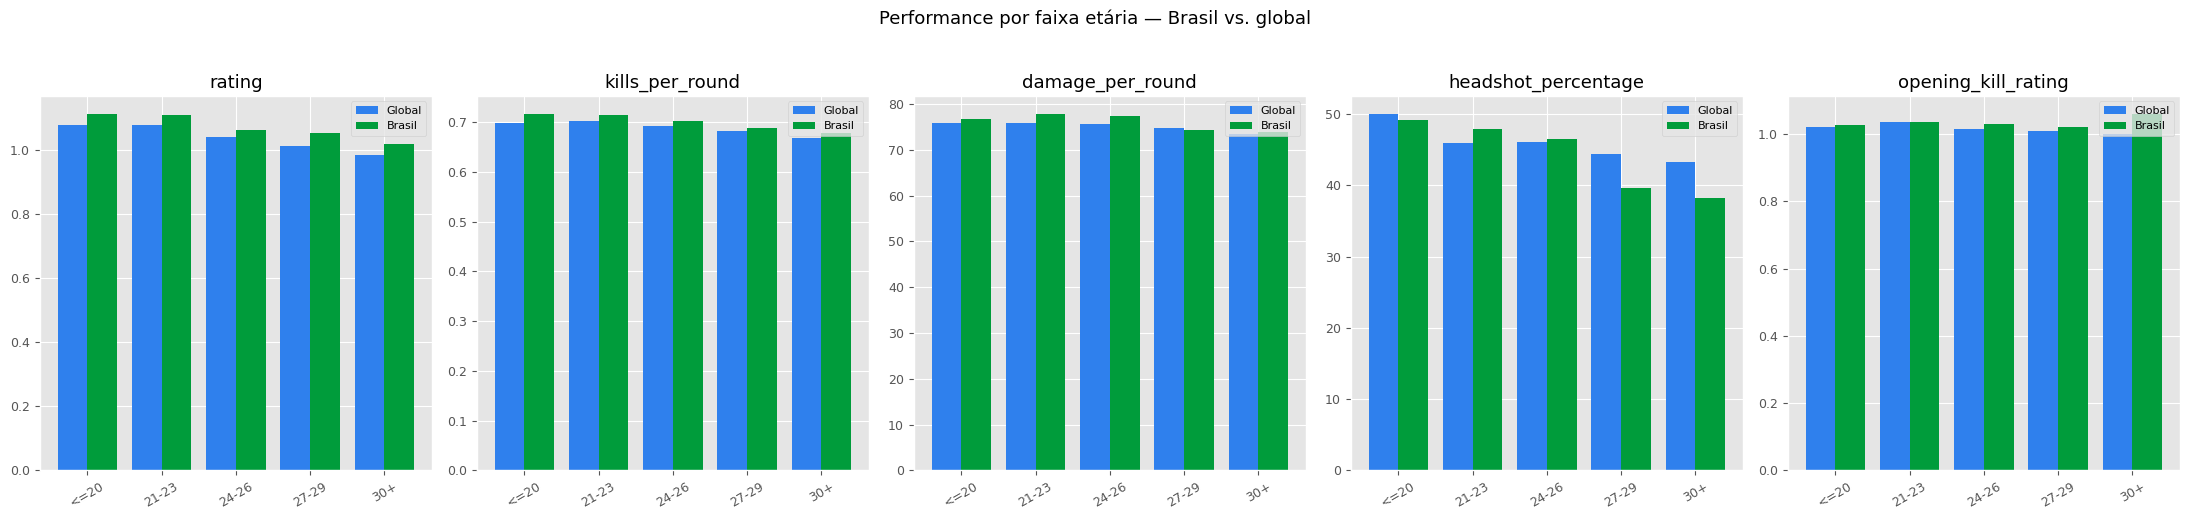

,rating,kills_per_round,damage_per_round,headshot_percentage,opening_kill_rating
age_group,,,,,
<=20,1.113,0.717,76.833,49.133,1.027
21-23,1.108,0.713,77.911,47.867,1.034
24-26,1.064,0.703,77.310,46.514,1.030
27-29,1.053,0.688,74.405,39.620,1.022
30+,1.019,0.678,73.950,38.250,1.060


In [6]:
age_metrics = ['rating', 'kills_per_round', 'damage_per_round',
               'headshot_percentage', 'opening_kill_rating']

br_by_age = brazil_df.groupby('age_group', observed=True)[age_metrics].mean()
world_by_age = df.groupby('age_group', observed=True)[age_metrics].mean()

fig, axes = plt.subplots(1, 5, figsize=(22, 5), sharex=True)

for ax, metric in zip(axes, age_metrics):
    x = np.arange(len(age_labels))
    width = 0.4
    ax.bar(x - width/2, world_by_age[metric].reindex(age_labels).values,
           width, color=WORLD_COLOR, label='Global')
    ax.bar(x + width/2, br_by_age[metric].reindex(age_labels).values,
           width, color=BR_COLOR, label='Brasil')
    ax.set_xticks(x)
    ax.set_xticklabels(age_labels, rotation=30)
    ax.set_title(metric)
    ax.legend(fontsize=8)

plt.suptitle('Performance por faixa etária — Brasil vs. global', y=1.03, fontsize=13)
plt.tight_layout()
plt.show()

br_by_age.round(3)

## 3. Melhores jogadores brasileiros

Ranking pelos principais indicadores e perfil de armas dos brasileiros em comparação à média global.

In [7]:
br_top10 = brazil_df.nlargest(10, 'rating')[
    ['nickname', 'real_name', 'age', 'current_team', 'rating',
     'kills_per_round', 'kills_per_death', 'damage_per_round',
     'headshot_percentage', 'opening_kill_rating', 'maps_played']
].reset_index(drop=True)
br_top10

,nickname,real_name,age,current_team,rating,kills_per_round,kills_per_death,damage_per_round,headshot_percentage,opening_kill_rating,maps_played
0,saffee,Rafael Costa,27,FURIA,1.22,0.79,1.30,80.2,30.9,1.14,404
1,KSCERATO,Kaike Cerato,22,FURIA,1.18,0.74,1.27,79.2,49.4,0.99,930
2,vsm,Vinicius Moreira,23,00NATION,1.18,0.77,1.16,83.6,47.0,1.12,533
3,yuurih,Yuri Santos,22,FURIA,1.18,0.76,1.19,84.2,44.3,1.03,1022
4,dumau,Eduardo Wolkmer,18,00NATION,1.16,0.74,1.18,80.2,41.6,1.07,473
5,biguzera,Rodrigo Bittencourt,25,paiN,1.16,0.73,1.15,80.6,51.2,1.03,622
6,coldzera,Marcelo David,27,00NATION,1.15,0.77,1.25,79.2,49.4,1.01,1426
7,JOTA,Jhonatan Willian,24,MIBR,1.15,0.73,1.14,82.2,41.6,1.04,430
8,nython,Gabriel Lino,24,paiN,1.14,0.75,1.16,76.7,37.6,1.15,524
9,trk,Alencar Rossato,27,TeamOne,1.14,0.73,1.10,79.4,48.2,1.01,830


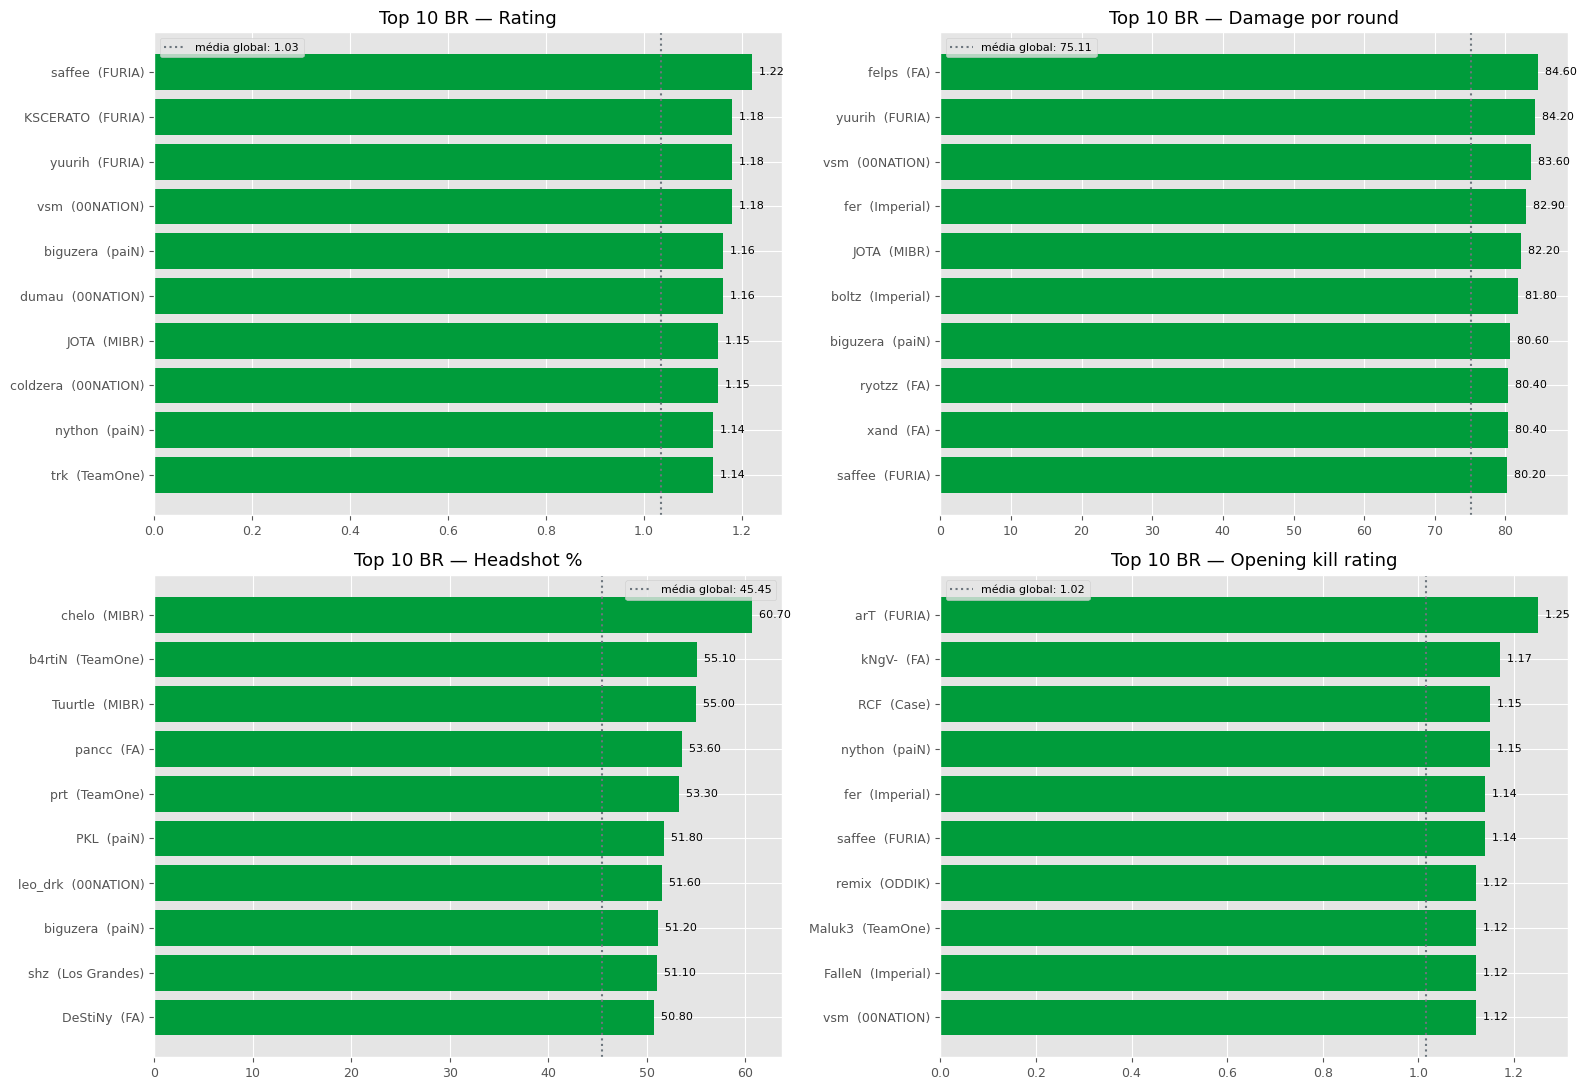

In [8]:
ranking_specs = [
    ('rating', 'Rating'),
    ('damage_per_round', 'Damage por round'),
    ('headshot_percentage', 'Headshot %'),
    ('opening_kill_rating', 'Opening kill rating')
]

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
axes = axes.flatten()

for ax, (metric, title) in zip(axes, ranking_specs):
    plot_data = brazil_df.nlargest(10, metric).sort_values(metric)
    labels = plot_data['nickname'] + '  (' + plot_data['current_team'].fillna('FA') + ')'
    ax.barh(labels, plot_data[metric], color=BR_COLOR)
    global_mean = df[metric].mean()
    ax.axvline(global_mean, color=NEUTRAL, linestyle=':', linewidth=1.5,
               label=f'média global: {global_mean:.2f}')
    for i, val in enumerate(plot_data[metric].values):
        ax.text(val, i, f'  {val:.2f}', va='center', fontsize=8)
    ax.set_title(f'Top 10 BR — {title}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

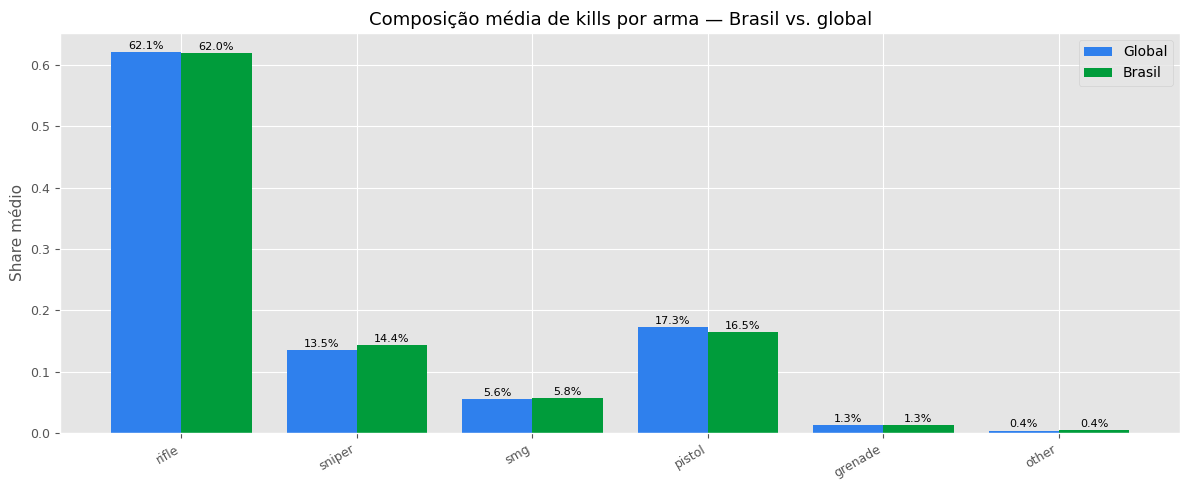

In [9]:
br_weapon_share = brazil_df[weapon_share_cols].mean()
world_weapon_share = df[weapon_share_cols].mean()

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(weapon_share_cols))
width = 0.4
ax.bar(x - width/2, world_weapon_share.values, width, color=WORLD_COLOR, label='Global')
ax.bar(x + width/2, br_weapon_share.values, width, color=BR_COLOR, label='Brasil')
ax.set_xticks(x)
ax.set_xticklabels([c.replace('_share', '') for c in weapon_share_cols], rotation=30, ha='right')
ax.set_title('Composição média de kills por arma — Brasil vs. global')
ax.set_ylabel('Share médio')

for i, (br_v, w_v) in enumerate(zip(br_weapon_share.values, world_weapon_share.values)):
    ax.text(i + width/2, br_v + 0.005, f'{br_v:.1%}', ha='center', fontsize=8)
    ax.text(i - width/2, w_v + 0.005, f'{w_v:.1%}', ha='center', fontsize=8)

ax.legend()
plt.tight_layout()
plt.show()

## 4. Times brasileiros

Times atuais com presença majoritária de brasileiros (≥ 3 brasileiros no elenco do dataset).

In [10]:
br_team_stats = (
    brazil_df.dropna(subset=['current_team'])
             .groupby('current_team')
             .agg(br_players=('player_id', 'count'),
                  avg_rating=('rating', 'mean'),
                  best_rating=('rating', 'max'),
                  avg_kpr=('kills_per_round', 'mean'),
                  avg_dpr=('damage_per_round', 'mean'),
                  avg_hs=('headshot_percentage', 'mean'),
                  avg_opening=('opening_kill_rating', 'mean'))
             .query('br_players >= 3')
             .sort_values('avg_rating', ascending=False)
             .round(3)
)
br_team_stats

,br_players,avg_rating,best_rating,avg_kpr,avg_dpr,avg_hs,avg_opening
current_team,,,,,,,
FURIA,4,1.168,1.22,0.750,80.425,39.850,1.102
00NATION,5,1.096,1.18,0.716,77.360,47.940,1.038
MIBR,5,1.078,1.15,0.700,77.640,50.120,1.014
TeamOne,6,1.075,1.14,0.697,75.717,46.267,1.013
paiN,5,1.072,1.16,0.704,76.340,47.120,1.040
Los Grandes,4,1.065,1.10,0.685,72.950,43.450,1.000
Imperial,5,1.054,1.08,0.700,77.680,42.660,1.042
Corinthians,3,1.010,1.05,0.677,73.200,39.533,1.023


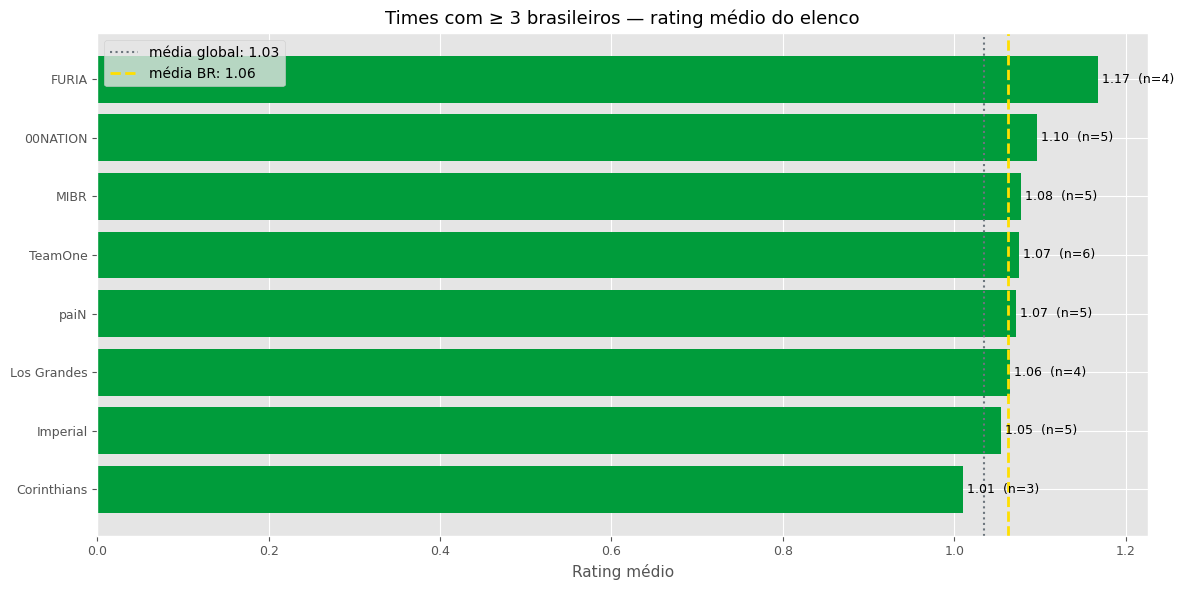

In [11]:
fig, ax = plt.subplots(figsize=(12, 6))
plot_data = br_team_stats.sort_values('avg_rating')
bars = ax.barh(plot_data.index, plot_data['avg_rating'], color=BR_COLOR)
ax.axvline(df['rating'].mean(), color=NEUTRAL, linestyle=':', linewidth=1.5,
           label=f'média global: {df["rating"].mean():.2f}')
ax.axvline(brazil_df['rating'].mean(), color=BR_ACCENT, linestyle='--', linewidth=2,
           label=f'média BR: {brazil_df["rating"].mean():.2f}')

for bar, val, n in zip(bars, plot_data['avg_rating'], plot_data['br_players']):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}  (n={int(n)})', va='center', fontsize=9)

ax.set_title('Times com ≥ 3 brasileiros — rating médio do elenco')
ax.set_xlabel('Rating médio')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Melhor brasileiro × melhor do mundo

Comparação direta entre o jogador brasileiro com maior `rating` no dataset e o jogador com maior `rating` global.

In [12]:
best_br = brazil_df.loc[brazil_df['rating'].idxmax()]
best_world = df.loc[df['rating'].idxmax()]

compare_cols = ['rating', 'kills_per_round', 'kills_per_death', 'damage_per_round',
                'headshot_percentage', 'opening_kill_rating', 'opening_kill_ratio',
                'assists_per_round', 'saved_teammates_per_round',
                'maps_played', 'rounds_played']

player_compare = pd.DataFrame({
    f'{best_br["nickname"]} (BR)': best_br[compare_cols],
    f'{best_world["nickname"]} ({best_world["country"]})': best_world[compare_cols],
}).round(3)
player_compare['Δ (BR - mundo)'] = (player_compare.iloc[:, 0] - player_compare.iloc[:, 1]).round(3)

print(f"Melhor BR : {best_br['nickname']} ({best_br['real_name']}, {best_br['age']} anos, {best_br['current_team']})")
print(f"Melhor mundo: {best_world['nickname']} ({best_world['real_name']}, {best_world['age']} anos, {best_world['country']} — {best_world['current_team']})")
player_compare

Melhor BR : saffee (Rafael Costa, 27 anos, FURIA)
Melhor mundo: ZywOo (Mathieu Herbaut, 21 anos, France — Vitality)


,saffee (BR),ZywOo (France),Δ (BR - mundo)
rating,1.22,1.32,-0.1
kills_per_round,0.79,0.84,-0.05
kills_per_death,1.3,1.37,-0.07
damage_per_round,80.2,88.0,-7.8
headshot_percentage,30.9,41.2,-10.3
opening_kill_rating,1.14,1.28,-0.14
opening_kill_ratio,1.47,1.6,-0.13
assists_per_round,0.1,0.12,-0.02
saved_teammates_per_round,0.1,0.12,-0.02
maps_played,404,1020,-616


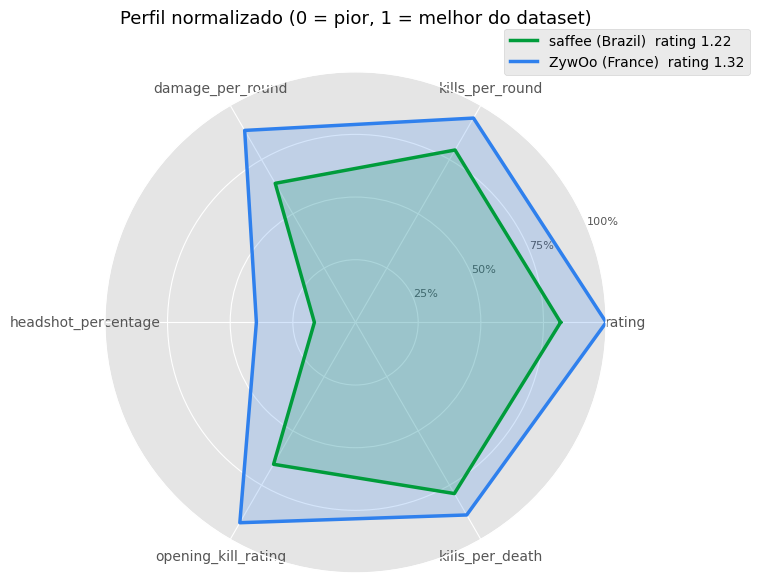

In [13]:
radar_metrics = ['rating', 'kills_per_round', 'damage_per_round',
                 'headshot_percentage', 'opening_kill_rating', 'kills_per_death']

mins = df[radar_metrics].min()
maxs = df[radar_metrics].max()

def normalize(row):
    return ((row[radar_metrics] - mins) / (maxs - mins)).tolist()

angles = np.linspace(0, 2 * np.pi, len(radar_metrics), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for player, color in [(best_br, BR_COLOR), (best_world, WORLD_COLOR)]:
    values = normalize(player)
    values += values[:1]
    label = f"{player['nickname']} ({player['country']})  rating {player['rating']:.2f}"
    ax.plot(angles, values, linewidth=2.5, color=color, label=label)
    ax.fill(angles, values, color=color, alpha=0.2)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_metrics, fontsize=10)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['25%', '50%', '75%', '100%'], fontsize=8)
ax.set_ylim(0, 1)
ax.set_title('Perfil normalizado (0 = pior, 1 = melhor do dataset)', y=1.08)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()

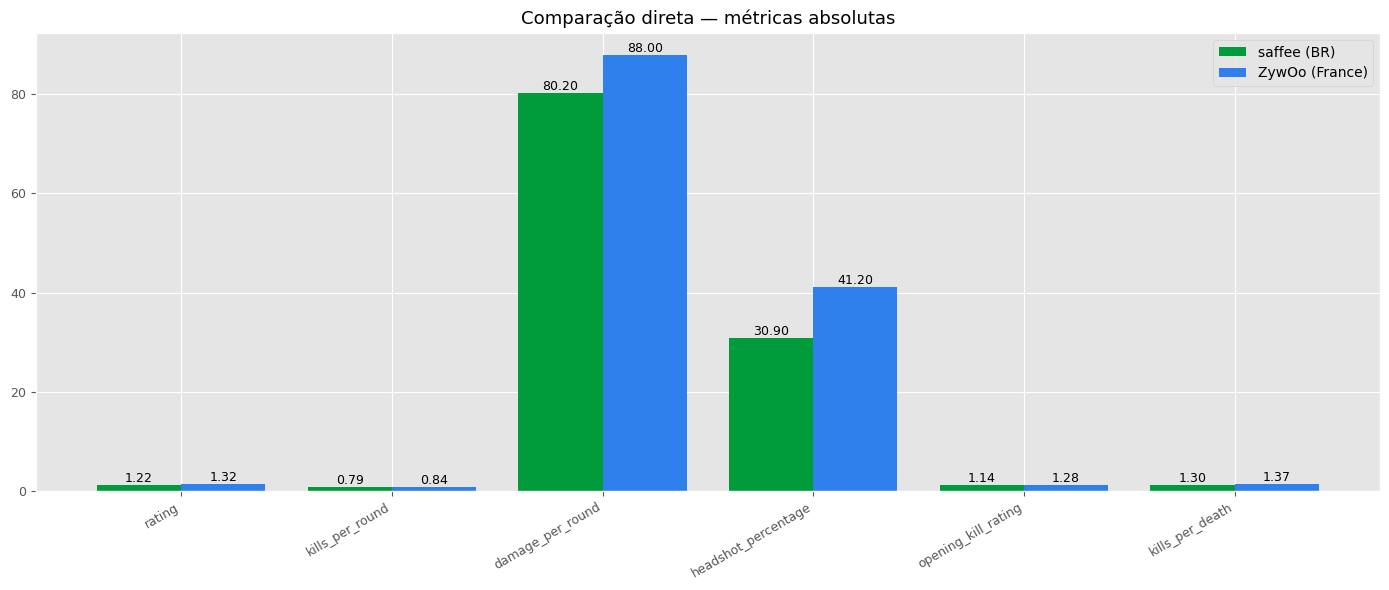

In [14]:
bar_metrics = ['rating', 'kills_per_round', 'damage_per_round',
               'headshot_percentage', 'opening_kill_rating', 'kills_per_death']

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(bar_metrics))
width = 0.4
ax.bar(x - width/2, best_br[bar_metrics].values, width, color=BR_COLOR,
       label=f"{best_br['nickname']} (BR)")
ax.bar(x + width/2, best_world[bar_metrics].values, width, color=WORLD_COLOR,
       label=f"{best_world['nickname']} ({best_world['country']})")

for i, (br_v, w_v) in enumerate(zip(best_br[bar_metrics].values, best_world[bar_metrics].values)):
    ax.text(i - width/2, br_v, f'{br_v:.2f}', ha='center', va='bottom', fontsize=9)
    ax.text(i + width/2, w_v, f'{w_v:.2f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(bar_metrics, rotation=30, ha='right')
ax.set_title('Comparação direta — métricas absolutas')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Melhor time brasileiro × melhor time do mundo

- **Melhor time brasileiro:** definido como o time com maior `rating` médio dentre aqueles com ≥ 3 brasileiros no elenco do dataset.
- **Melhor time do mundo:** time com maior `rating` médio entre os que têm ≥ 5 jogadores no dataset (filtro de elenco competitivo).

In [15]:
world_team_ranking = (
    df.dropna(subset=['current_team'])
      .groupby('current_team')
      .agg(players=('player_id', 'count'),
           avg_rating=('rating', 'mean'),
           avg_kpr=('kills_per_round', 'mean'),
           avg_dpr=('damage_per_round', 'mean'),
           avg_hs=('headshot_percentage', 'mean'),
           avg_opening=('opening_kill_rating', 'mean'),
           avg_kd=('kills_per_death', 'mean'))
      .query('players >= 5')
      .sort_values('avg_rating', ascending=False)
      .round(3)
)

best_br_team_name = br_team_stats.index[0]
best_world_team_name = world_team_ranking.index[0]

print(f'Melhor time BR : {best_br_team_name}  (média {br_team_stats.loc[best_br_team_name, "avg_rating"]})')
print(f'Melhor time mundo: {best_world_team_name}  (média {world_team_ranking.loc[best_world_team_name, "avg_rating"]})')

team_compare_cols = ['avg_rating', 'avg_kpr', 'avg_dpr', 'avg_hs', 'avg_opening']
team_compare = pd.DataFrame({
    best_br_team_name + ' (BR)': br_team_stats.loc[best_br_team_name].rename({
        'avg_rating': 'avg_rating', 'avg_kpr': 'avg_kpr', 'avg_dpr': 'avg_dpr',
        'avg_hs': 'avg_hs', 'avg_opening': 'avg_opening'})[team_compare_cols],
    best_world_team_name + ' (mundo)': world_team_ranking.loc[best_world_team_name][team_compare_cols]
}).round(3)
team_compare['Δ (BR - mundo)'] = (team_compare.iloc[:, 0] - team_compare.iloc[:, 1]).round(3)
team_compare

Melhor time BR : FURIA  (média 1.168)
Melhor time mundo: ORDER  (média 1.138)


,FURIA (BR),ORDER (mundo),Δ (BR - mundo)
avg_rating,1.168,1.138,0.030
avg_kpr,0.750,0.732,0.018
avg_dpr,80.425,79.300,1.125
avg_hs,39.850,41.960,-2.110
avg_opening,1.102,1.082,0.020


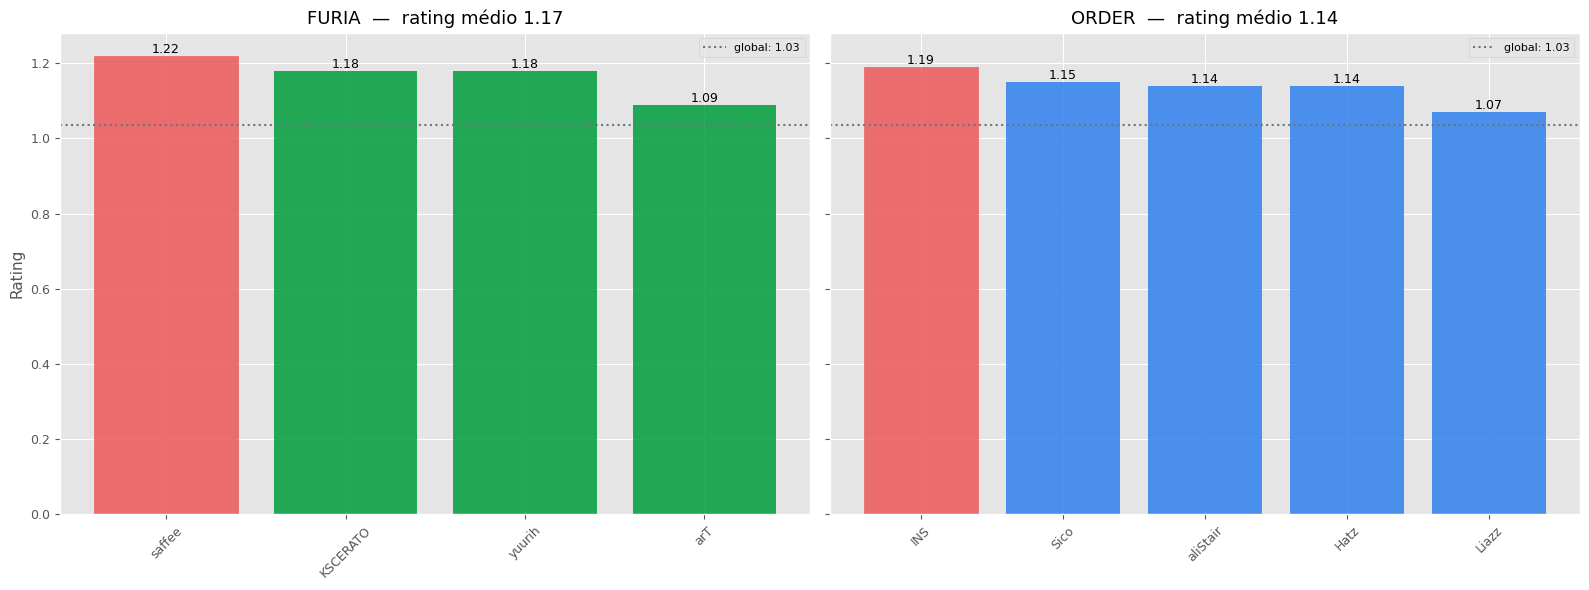


Elenco FURIA:
nickname country  age  rating  kills_per_round  damage_per_round  headshot_percentage  opening_kill_rating
  saffee  Brazil   27    1.22             0.79              80.2                 30.9                 1.14
KSCERATO  Brazil   22    1.18             0.74              79.2                 49.4                 0.99
  yuurih  Brazil   22    1.18             0.76              84.2                 44.3                 1.03
     arT  Brazil   26    1.09             0.71              78.1                 34.8                 1.25

Elenco ORDER:
nickname     country  age  rating  kills_per_round  damage_per_round  headshot_percentage  opening_kill_rating
     INS   Australia   23    1.19             0.76              85.6                 42.5                 1.08
    Sico New Zealand   27    1.15             0.75              79.1                 35.4                 1.13
aliStair   Australia   24    1.14             0.73              76.0                 35.1             

In [16]:
best_br_team_df = df[df['current_team'] == best_br_team_name].sort_values('rating', ascending=False).reset_index(drop=True)
best_world_team_df = df[df['current_team'] == best_world_team_name].sort_values('rating', ascending=False).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for ax, team_df, team_name, color in [
    (axes[0], best_br_team_df, best_br_team_name, BR_COLOR),
    (axes[1], best_world_team_df, best_world_team_name, WORLD_COLOR),
]:
    bars = ax.bar(team_df['nickname'], team_df['rating'], color=color, alpha=0.85)
    bars[0].set_color(HIGHLIGHT)
    for bar, val in zip(bars, team_df['rating']):
        ax.text(bar.get_x() + bar.get_width()/2, val,
                f'{val:.2f}', ha='center', va='bottom', fontsize=9)
    ax.axhline(df['rating'].mean(), color=NEUTRAL, linestyle=':',
               label=f'global: {df["rating"].mean():.2f}')
    ax.set_title(f"{team_name}  —  rating médio {team_df['rating'].mean():.2f}")
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=8)

axes[0].set_ylabel('Rating')
plt.tight_layout()
plt.show()

print(f'\nElenco {best_br_team_name}:')
print(best_br_team_df[['nickname', 'country', 'age', 'rating', 'kills_per_round',
                       'damage_per_round', 'headshot_percentage', 'opening_kill_rating']].to_string(index=False))
print(f'\nElenco {best_world_team_name}:')
print(best_world_team_df[['nickname', 'country', 'age', 'rating', 'kills_per_round',
                          'damage_per_round', 'headshot_percentage', 'opening_kill_rating']].to_string(index=False))

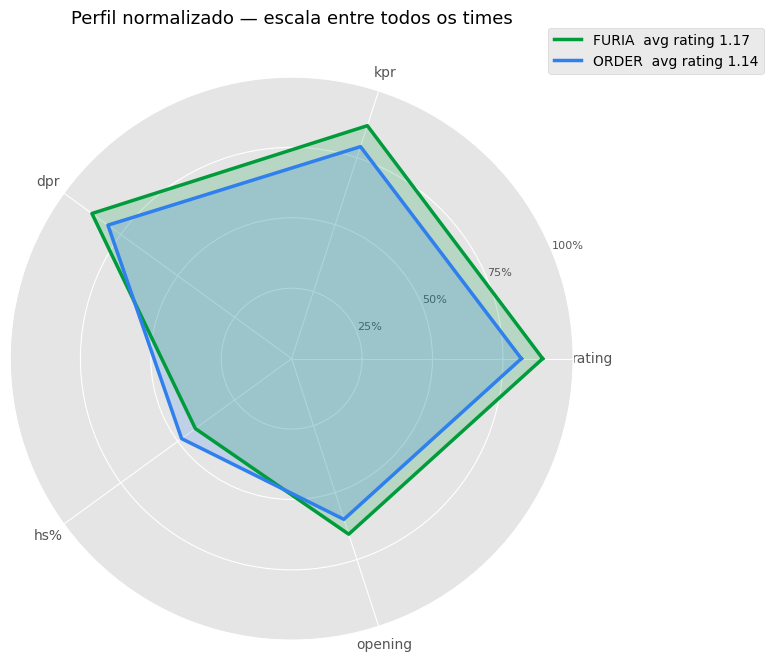

In [17]:
team_radar_metrics = ['avg_rating', 'avg_kpr', 'avg_dpr', 'avg_hs', 'avg_opening']

all_teams_panel = (df.dropna(subset=['current_team'])
                     .groupby('current_team')
                     .agg(avg_rating=('rating', 'mean'),
                          avg_kpr=('kills_per_round', 'mean'),
                          avg_dpr=('damage_per_round', 'mean'),
                          avg_hs=('headshot_percentage', 'mean'),
                          avg_opening=('opening_kill_rating', 'mean')))

t_mins = all_teams_panel[team_radar_metrics].min()
t_maxs = all_teams_panel[team_radar_metrics].max()

def norm_team(name):
    row = all_teams_panel.loc[name]
    return ((row[team_radar_metrics] - t_mins) / (t_maxs - t_mins)).tolist()

angles = np.linspace(0, 2 * np.pi, len(team_radar_metrics), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for team_name, color in [(best_br_team_name, BR_COLOR), (best_world_team_name, WORLD_COLOR)]:
    values = norm_team(team_name)
    values += values[:1]
    label = f'{team_name}  avg rating {all_teams_panel.loc[team_name, "avg_rating"]:.2f}'
    ax.plot(angles, values, linewidth=2.5, color=color, label=label)
    ax.fill(angles, values, color=color, alpha=0.2)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(['rating', 'kpr', 'dpr', 'hs%', 'opening'], fontsize=10)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['25%', '50%', '75%', '100%'], fontsize=8)
ax.set_ylim(0, 1)
ax.set_title('Perfil normalizado — escala entre todos os times', y=1.08)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1))
plt.tight_layout()
plt.show()

## 7. Resumo executivo

Síntese dos KPIs principais que entram no relatório do Power BI.

In [18]:
kpis = pd.DataFrame([
    {'KPI': 'Jogadores brasileiros',                  'Brasil': len(brazil_df),                                'Mundo': len(df)},
    {'KPI': 'Idade média',                            'Brasil': round(brazil_df['age'].mean(), 2),             'Mundo': round(df['age'].mean(), 2)},
    {'KPI': 'Rating médio',                           'Brasil': round(brazil_df['rating'].mean(), 3),          'Mundo': round(df['rating'].mean(), 3)},
    {'KPI': 'Kills por round (médio)',                'Brasil': round(brazil_df['kills_per_round'].mean(), 3), 'Mundo': round(df['kills_per_round'].mean(), 3)},
    {'KPI': 'Damage por round (médio)',               'Brasil': round(brazil_df['damage_per_round'].mean(), 2),'Mundo': round(df['damage_per_round'].mean(), 2)},
    {'KPI': 'Headshot % (médio)',                     'Brasil': round(brazil_df['headshot_percentage'].mean(), 2),'Mundo': round(df['headshot_percentage'].mean(), 2)},
    {'KPI': 'Opening kill rating (médio)',            'Brasil': round(brazil_df['opening_kill_rating'].mean(), 3),'Mundo': round(df['opening_kill_rating'].mean(), 3)},
    {'KPI': 'Melhor jogador (rating)',                'Brasil': f'{best_br["nickname"]} ({best_br["rating"]})', 'Mundo': f'{best_world["nickname"]} ({best_world["rating"]})'},
    {'KPI': 'Melhor time (rating médio)',             'Brasil': f'{best_br_team_name} ({br_team_stats.loc[best_br_team_name, "avg_rating"]})',
                                                       'Mundo': f'{best_world_team_name} ({world_team_ranking.loc[best_world_team_name, "avg_rating"]})'},
])
kpis

,KPI,Brasil,Mundo
0,Jogadores brasileiros,61,811
1,Idade média,25.92,25.85
2,Rating médio,1.063,1.034
3,Kills por round (médio),0.697,0.688
4,Damage por round (médio),75.98,75.11
5,Headshot % (médio),43.5,45.45
6,Opening kill rating (médio),1.031,1.015
7,Melhor jogador (rating),saffee (1.22),ZywOo (1.32)
8,Melhor time (rating médio),FURIA (1.168),ORDER (1.138)


## 8. Exportações para Power BI

Geramos uma pasta `powerbi/` com os datasets que alimentam o relatório.

| Arquivo | Conteúdo |
|---|---|
| `players_full.csv` | Dataset limpo de todos os 811 jogadores |
| `players_brazil.csv` | Subset dos brasileiros |
| `country_stats.csv` | Estatísticas agregadas por país (≥ 10 jogadores) |
| `team_stats_world.csv` | Ranking mundial de times (≥ 5 jogadores) |
| `team_stats_brazil.csv` | Times com ≥ 3 brasileiros |
| `age_group_compare.csv` | Médias por faixa etária — BR e global |
| `best_player_compare.csv` | Comparação melhor BR × melhor mundo (long-format) |
| `best_team_compare.csv` | Comparação melhor time BR × melhor time mundo (long-format) |
| `kpis_brazil.csv` | KPIs principais |

In [19]:
import os
os.makedirs('powerbi', exist_ok=True)

df.to_csv('powerbi/players_full.csv', index=False, encoding='utf-8-sig')
brazil_df.to_csv('powerbi/players_brazil.csv', index=False, encoding='utf-8-sig')

country_stats = (
    df.groupby('country')
      .agg(players=('player_id', 'count'),
           avg_rating=('rating', 'mean'),
           avg_kpr=('kills_per_round', 'mean'),
           avg_dpr=('damage_per_round', 'mean'),
           avg_hs=('headshot_percentage', 'mean'),
           avg_opening=('opening_kill_rating', 'mean'),
           avg_age=('age', 'mean'))
      .query('players >= 10')
      .sort_values('avg_rating', ascending=False)
      .round(3)
)
country_stats.to_csv('powerbi/country_stats.csv', encoding='utf-8-sig')

world_team_ranking.to_csv('powerbi/team_stats_world.csv', encoding='utf-8-sig')
br_team_stats.to_csv('powerbi/team_stats_brazil.csv', encoding='utf-8-sig')

age_group_compare = pd.concat([
    brazil_df.groupby('age_group', observed=True)[age_metrics].mean().assign(scope='Brasil'),
    df.groupby('age_group', observed=True)[age_metrics].mean().assign(scope='Mundo')
]).reset_index()
age_group_compare.to_csv('powerbi/age_group_compare.csv', index=False, encoding='utf-8-sig')

player_long = player_compare.drop(columns=['Δ (BR - mundo)']).reset_index().rename(columns={'index': 'metric'}).melt(
    id_vars='metric', var_name='player', value_name='value'
)
player_long.to_csv('powerbi/best_player_compare.csv', index=False, encoding='utf-8-sig')

team_long = team_compare.drop(columns=['Δ (BR - mundo)']).reset_index().rename(columns={'index': 'metric'}).melt(
    id_vars='metric', var_name='team', value_name='value'
)
team_long.to_csv('powerbi/best_team_compare.csv', index=False, encoding='utf-8-sig')

kpis.to_csv('powerbi/kpis_brazil.csv', index=False, encoding='utf-8-sig')

print('Arquivos exportados em powerbi/:')
for f in sorted(os.listdir('powerbi')):
    size_kb = os.path.getsize(f'powerbi/{f}') / 1024
    print(f'  - {f}  ({size_kb:.1f} KB)')

Arquivos exportados em powerbi/:
  - age_group_compare.csv  (1.0 KB)
  - best_player_compare.csv  (0.8 KB)
  - best_team_compare.csv  (0.3 KB)
  - country_stats.csv  (1.0 KB)
  - kpis_brazil.csv  (0.4 KB)
  - players_brazil.csv  (22.5 KB)
  - players_full.csv  (293.4 KB)
  - team_stats_brazil.csv  (0.4 KB)
  - team_stats_world.csv  (1.8 KB)


## 9. Conclusões para o relatório

Pontos-chave a destacar no Power BI:

- **Tamanho da cena BR.** Brasil é o 4º maior contingente do dataset (61 jogadores), atrás apenas de EUA, Dinamarca e Rússia.
- **Brasil acima da média.** Rating médio BR (1,063) > rating médio global (1,034); destaques em K/D, opening duels e damage por round. Calcanhar: **headshot % (43,5% vs. 45,5%)**.
- **Idade × performance.** Correlação negativa entre idade e rating: −0,448 no Brasil, −0,462 no mundo — comportamento muito similar, ambos com pico na faixa 21–23 anos.
- **Concentração de talento.** Top brasileiros estão majoritariamente em FURIA, 00NATION e paiN.
- **Melhor jogador BR × mundo:** **saffee (FURIA, rating 1,22)** contra **ZywOo (Vitality, rating 1,32)** — gap de −0,10 no rating, com diferenças mais expressivas em **headshot % (−10,3 pp)** e **opening kill rating (−0,14)**.
- **Melhor time BR × mundo:** **FURIA (avg rating 1,168)** contra **ORDER (avg rating 1,138)**. Pelo critério usado (≥ 3 BRs para times brasileiros, ≥ 5 jogadores para o ranking mundial), **FURIA aparece acima**. Importante destacar que FURIA tem apenas 4 jogadores no dataset, abaixo do corte global de 5 — então a comparação não é totalmente "apples-to-apples", mas mostra que o núcleo da FURIA performa em nível de elite mundial.

Os datasets na pasta `powerbi/` podem ser importados diretamente pelo Power BI Desktop (`Get Data → Text/CSV`, encoding UTF-8-BOM já configurado para preservar acentos).

## 10. Tabela para o Radar (comparador dinâmico de jogadores)

Para o radar no Power BI funcionar com **qualquer jogador** e de forma justa, geramos uma tabela em **formato longo** e **normalizada (0–100 por métrica via min-max sobre os 811 jogadores)**.

Saída: `powerbi/player_radar.csv` com as colunas:

| Coluna | Descrição |
|---|---|
| `player_id`, `nickname`, `country`, `current_team`, `age` | identificação (para a lista/slicer e cards) |
| `metric` | nome da métrica (eixo do radar) |
| `value_real` | valor original (para tooltip) |
| `value_norm` | valor normalizado 0–100 (forma do radar) |

Métricas escolhidas (todas "quanto maior, melhor"): `rating`, `kills_per_round`, `kills_per_death`, `damage_per_round`, `headshot_percentage`, `opening_kill_rating`, `assists_per_round`, `saved_teammates_per_round`.

In [2]:
import os
import pandas as pd

# Esta célula é independente: se o notebook não tiver criado df ainda,
# ela carrega e limpa o CSV automaticamente.
if 'df' not in globals():
    df = pd.read_csv('csgo_players.csv')

    pct_cols = ['headshot_percentage', 'team_win_percent_after_first_kill', 'first_kill_in_won_rounds']
    for c in pct_cols:
        if c in df.columns and not pd.api.types.is_numeric_dtype(df[c]):
            df[c] = df[c].astype(str).str.rstrip('%').astype(float)

radar_metrics = ['rating', 'kills_per_round', 'kills_per_death', 'damage_per_round',
                 'headshot_percentage', 'opening_kill_rating', 'assists_per_round',
                 'saved_teammates_per_round']

id_cols = ['player_id', 'nickname', 'country', 'current_team', 'age']

radar_base = df[id_cols + radar_metrics].copy()

# Normalização min-max (0-100) por métrica, sobre todos os 811 jogadores.
# Isso deixa o radar justo mesmo com métricas em escalas diferentes.
norm = radar_base[radar_metrics].copy()
for m in radar_metrics:
    lo, hi = df[m].min(), df[m].max()
    norm[m] = (df[m] - lo) / (hi - lo) * 100

real_long = radar_base.melt(id_vars=id_cols, value_vars=radar_metrics,
                            var_name='metric', value_name='value_real')
norm_long = norm.assign(**{c: radar_base[c] for c in id_cols}).melt(
    id_vars=id_cols, value_vars=radar_metrics,
    var_name='metric', value_name='value_norm'
)

player_radar = real_long.merge(norm_long, on=id_cols + ['metric'])
player_radar['value_norm'] = player_radar['value_norm'].round(2)
player_radar['value_real'] = player_radar['value_real'].round(3)

os.makedirs('powerbi', exist_ok=True)
player_radar.to_csv('powerbi/player_radar.csv', index=False, encoding='utf-8-sig')

print(f'player_radar.csv gerado: {player_radar.shape[0]} linhas '
      f'({df.shape[0]} jogadores x {len(radar_metrics)} métricas)')
player_radar[player_radar['nickname'].isin(['saffee', 'ZywOo'])].pivot_table(
    index=['nickname'], columns='metric', values='value_norm'
)

player_radar.csv gerado: 6488 linhas (811 jogadores x 8 métricas)


metric,assists_per_round,damage_per_round,headshot_percentage,kills_per_death,kills_per_round,opening_kill_rating,rating,saved_teammates_per_round
nickname,,,,,,,,
ZywOo,40.0,88.44,39.55,88.73,94.12,92.31,100.00,60.0
saffee,20.0,64.06,16.40,78.87,79.41,65.38,81.82,40.0


## 11. Machine Learning — Naive Bayes

Vamos treinar um classificador **Naive Bayes** para prever o **papel do jogador**:

- **Classe (alvo):** `role` = `AWPer` se o jogador tem mais kills de sniper que de rifle, senão `Rifler`.
- **Previsores:** idade, país, time, e métricas de performance (kpr, dpr, HS%, opening, etc.).

Rotina seguida:

1. Dividir previsores (X) e classe (y).
2. Ajustar previsores de texto (`country`, `current_team`) para numérico via `LabelEncoder`.
3. Dividir treino/teste com `train_test_split`.
4. Criar o modelo `GaussianNB`.
5. Gerar previsões com `predict`.
6. Gerar a matriz de confusão e a % de acerto.
7. Testar o modelo com um novo valor.

> Observação: as colunas de arma (`sniper_kills`, `rifle_kills`, `*_share`) **não** entram nos previsores, porque a classe é derivada delas (evita vazamento / data leakage).

In [3]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Célula independente: carrega/limpa o CSV se df ainda não existir
if 'df' not in globals():
    df = pd.read_csv('csgo_players.csv')
    for c in ['headshot_percentage', 'team_win_percent_after_first_kill', 'first_kill_in_won_rounds']:
        if c in df.columns and not pd.api.types.is_numeric_dtype(df[c]):
            df[c] = df[c].astype(str).str.rstrip('%').astype(float)

# Classe alvo: papel do jogador
df['role'] = np.where(df['sniper_kills'] > df['rifle_kills'], 'AWPer', 'Rifler')

print('Distribuição das classes:')
print(df['role'].value_counts())
print(f"\nProporção AWPers: {(df['role'] == 'AWPer').mean():.1%}")

Distribuição das classes:
role
Rifler    675
AWPer     136
Name: count, dtype: int64

Proporção AWPers: 16.8%


In [4]:
# 1) Dividir previsores (X) e classe (y)
feature_cols = ['age', 'country', 'current_team',
                'kills_per_round', 'deaths_per_round', 'kills_per_death',
                'headshot_percentage', 'damage_per_round',
                'opening_kill_rating', 'assists_per_round', 'saved_teammates_per_round']

X = df[feature_cols].copy()
y = df['role'].copy()

# 2) Ajustar previsores de texto para numérico (LabelEncoder)
# current_team tem nulos -> preenche antes de codificar
X['current_team'] = X['current_team'].fillna('Sem time')

encoders = {}
for col in ['country', 'current_team']:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    encoders[col] = le

print('Previsores após codificação (amostra):')
X.head()

Previsores após codificação (amostra):


,age,country,current_team,kills_per_round,deaths_per_round,kills_per_death,headshot_percentage,damage_per_round,opening_kill_rating,assists_per_round,saved_teammates_per_round
0,21,13,168,0.84,0.61,1.37,41.2,88.0,1.28,0.12,0.12
1,24,48,115,0.86,0.64,1.34,41.3,86.4,1.24,0.10,0.11
2,21,37,34,0.77,0.53,1.45,27.8,78.6,1.15,0.11,0.11
3,21,37,2,0.80,0.59,1.37,36.7,80.4,1.13,0.10,0.11
4,27,5,61,0.79,0.61,1.30,30.9,80.2,1.14,0.10,0.10


In [5]:
# 3) Divisão treino / teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f'Treino: {X_train.shape[0]} jogadores')
print(f'Teste:  {X_test.shape[0]} jogadores')

Treino: 608 jogadores
Teste:  203 jogadores


In [6]:
# 4) Criar e treinar o modelo Naive Bayes
modelo = GaussianNB()
modelo.fit(X_train, y_train)

print('Modelo GaussianNB treinado.')
print('Classes:', modelo.classes_)

Modelo GaussianNB treinado.
Classes: ['AWPer' 'Rifler']


Acurácia (% de acerto): 97.54%

Relatório de classificação:
              precision    recall  f1-score   support

       AWPer       0.89      0.97      0.93        34
      Rifler       0.99      0.98      0.99       169

    accuracy                           0.98       203
   macro avg       0.94      0.97      0.96       203
weighted avg       0.98      0.98      0.98       203



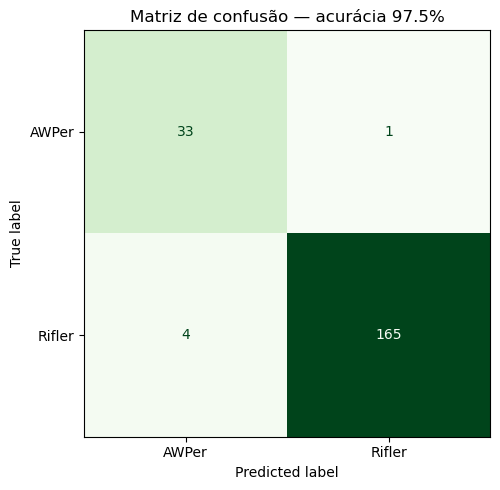

In [7]:
# 5) Gerar previsões
previsoes = modelo.predict(X_test)

# 6) Matriz de confusão e % de acerto
acuracia = accuracy_score(y_test, previsoes)
matriz = confusion_matrix(y_test, previsoes, labels=modelo.classes_)

print(f'Acurácia (% de acerto): {acuracia:.2%}\n')
print('Relatório de classificação:')
print(classification_report(y_test, previsoes))

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=matriz, display_labels=modelo.classes_)
disp.plot(ax=ax, cmap='Greens', colorbar=False)
ax.set_title(f'Matriz de confusão — acurácia {acuracia:.1%}')
plt.tight_layout()
plt.show()

In [9]:
# 7) Testar o modelo com um novo valor
# Perfil de um jogador hipotético (ex.: estilo AWPer — HS% baixo, opening alto)
novo_jogador = pd.DataFrame([{
    'age': 24,
    'country': 'Brazil',
    'current_team': 'FURIA',
    'kills_per_round': 0.78,
    'deaths_per_round': 0.62,
    'kills_per_death': 1.26,
    'headshot_percentage': 28.0,
    'damage_per_round': 80.0,
    'opening_kill_rating': 1.20,
    'assists_per_round': 0.08,
    'saved_teammates_per_round': 0.10,
}])

# Aplica os MESMOS encoders do treino
for col in ['country', 'current_team']:
    novo_jogador[col] = encoders[col].transform(novo_jogador[col].astype(str))

novo_jogador = novo_jogador[feature_cols]

pred = modelo.predict(novo_jogador)[0]
proba = modelo.predict_proba(novo_jogador)[0]

print(f'Previsão do papel: {pred}')
print('Probabilidades:')
for classe, p in zip(modelo.classes_, proba):
    print(f'  {classe}: {p:.1%}')

Previsão do papel: AWPer
Probabilidades:
  AWPer: 100.0%
  Rifler: 0.0%
